# **Setup and Configurations**

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAW_LBL_DIR = "../data/raw/train/labels/"
RAW_IMG_DIR = "../data/raw/train/images/"

CLASS_NAMES = {
    0: "Missing Hole",
    1: "Mouse Bite",
    2: "Open Circuit",
    3: "Short",
    4: "Spur",
    5: "Spurious Copper"
}

# **Data Extraction**

In [2]:
label_paths = glob.glob(os.path.join(RAW_LBL_DIR, "*.txt"))
defects_data = []

for lbl_path in label_paths:
    with open(lbl_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                defects_data.append({
                    "Class": CLASS_NAMES.get(int(parts[0]), "Unknown"),
                    "Width": float(parts[3]),
                    "Height": float(parts[4])
                })

df = pd.DataFrame(defects_data)
print(f"Total defects found in training set: {len(df)}")

Total defects found in training set: 11812


# **Class Distribution Plot**

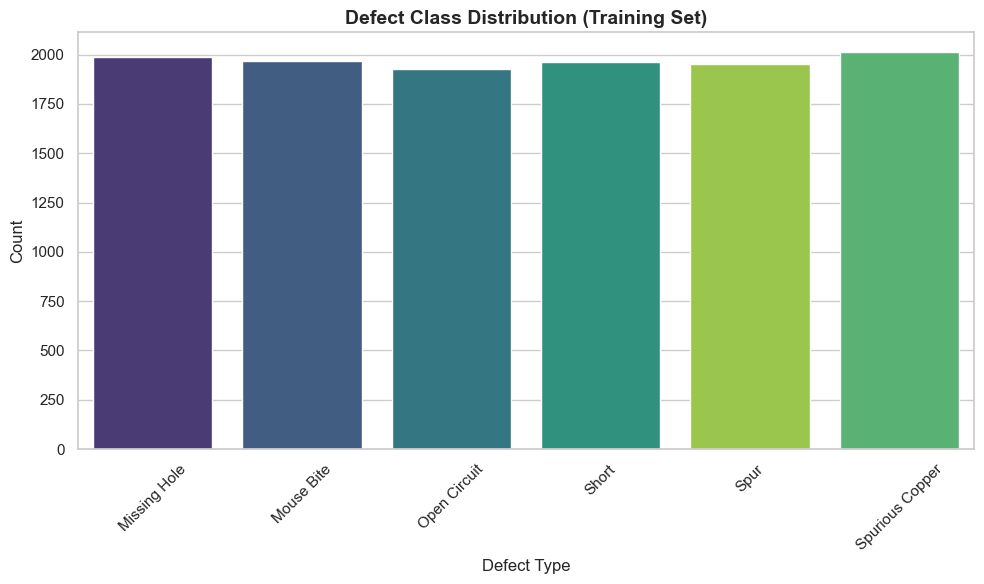

In [3]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Class", order=[CLASS_NAMES[i] for i in range(6)], palette="viridis", hue="Class", legend=False)
plt.title("Defect Class Distribution (Training Set)", fontsize=14, fontweight='bold')
plt.xlabel("Defect Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Bounding Box Size Chart**

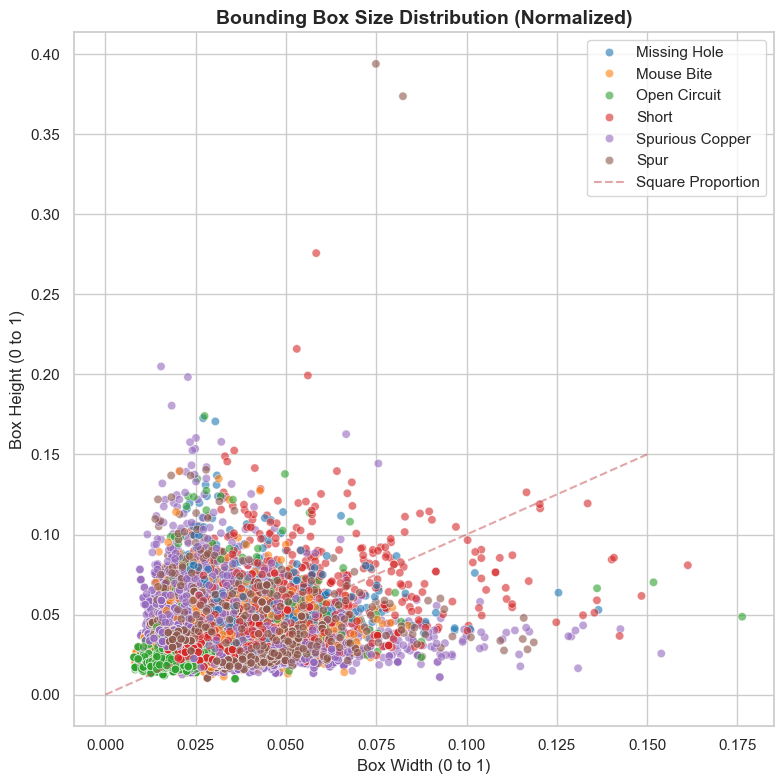

In [4]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df, x="Width", y="Height", hue="Class", alpha=0.6, palette="tab10")
plt.title("Bounding Box Size Distribution (Normalized)", fontsize=14, fontweight='bold')
plt.xlabel("Box Width (0 to 1)", fontsize=12)
plt.ylabel("Box Height (0 to 1)", fontsize=12)
plt.plot([0, 0.15], [0, 0.15], 'r--', alpha=0.5, label='Square Proportion')
plt.legend()
plt.tight_layout()
plt.show()

# **Calculate Image Metrics**

In [5]:
import cv2
import numpy as np

# Calculate the blur and brightness for every image
metrics_data = []
img_paths = glob.glob("../data/raw/train/images/*.jpg")

print(f"Analyzing {len(img_paths)} images for Blur and Brightness...")

for img_path in img_paths:
    img = cv2.imread(img_path)
    if img is None: 
        continue
        
    # Convert to grayscale for metric calculations
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 1. Calculate Brightness (Mean pixel intensity: 0 is black, 255 is white)
    brightness = np.mean(gray)
    
    # 2. Calculate Blur using Variance of Laplacian (Lower score = blurrier image)
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    
    metrics_data.append({"Image": os.path.basename(img_path), "Brightness": brightness, "Blur_Score": blur_score})

df_metrics = pd.DataFrame(metrics_data)
df_metrics.describe()

Analyzing 2772 images for Blur and Brightness...


,Brightness,Blur_Score
count,2772.000000,2772.000000
mean,60.821494,1941.015391
std,17.932763,2307.304013
min,13.301886,6.064902
25%,51.918265,72.530480
50%,58.395187,129.703747
75%,67.412760,4533.094880
max,155.626080,6214.946911


# **Visualize the Metrics**

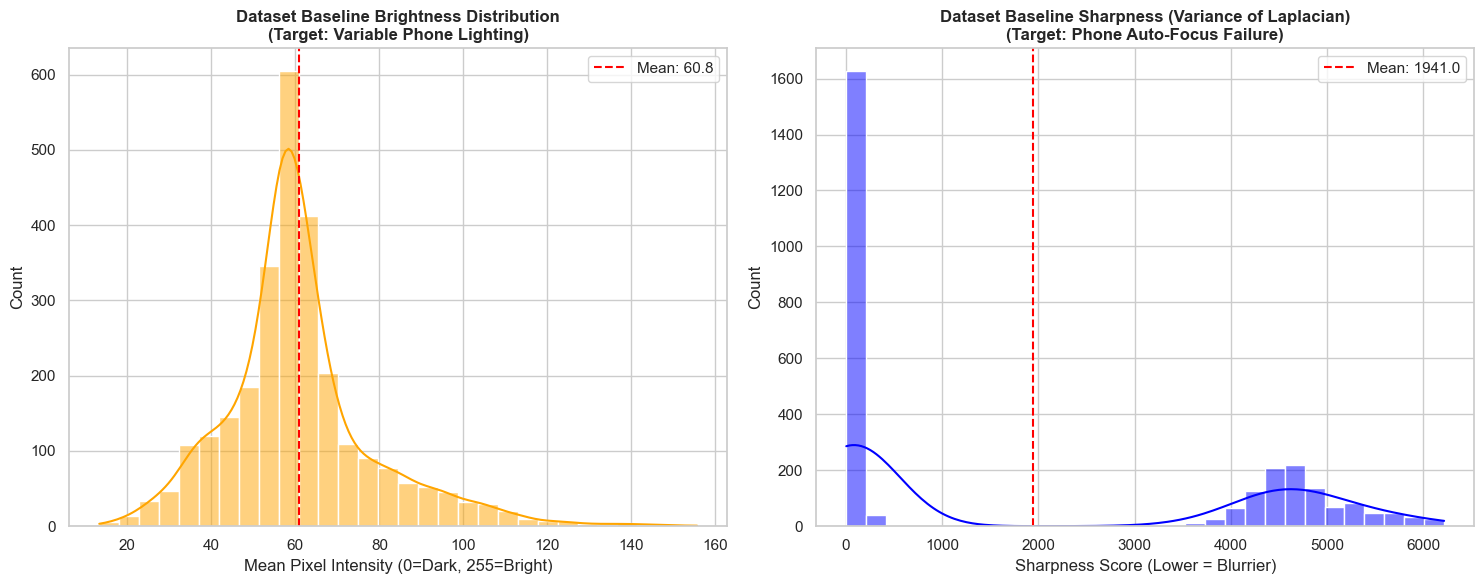

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram for Brightness
sns.histplot(data=df_metrics, x="Brightness", bins=30, kde=True, ax=axes[0], color="orange")
axes[0].set_title("Dataset Baseline Brightness Distribution\n(Target: Variable Phone Lighting)", fontweight='bold')
axes[0].set_xlabel("Mean Pixel Intensity (0=Dark, 255=Bright)")
axes[0].axvline(df_metrics['Brightness'].mean(), color='red', linestyle='--', label=f"Mean: {df_metrics['Brightness'].mean():.1f}")
axes[0].legend()

# Histogram for Blur
sns.histplot(data=df_metrics, x="Blur_Score", bins=30, kde=True, ax=axes[1], color="blue")
axes[1].set_title("Dataset Baseline Sharpness (Variance of Laplacian)\n(Target: Phone Auto-Focus Failure)", fontweight='bold')
axes[1].set_xlabel("Sharpness Score (Lower = Blurrier)")
axes[1].axvline(df_metrics['Blur_Score'].mean(), color='red', linestyle='--', label=f"Mean: {df_metrics['Blur_Score'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

# **Visualizing the Augmentation Prototype**

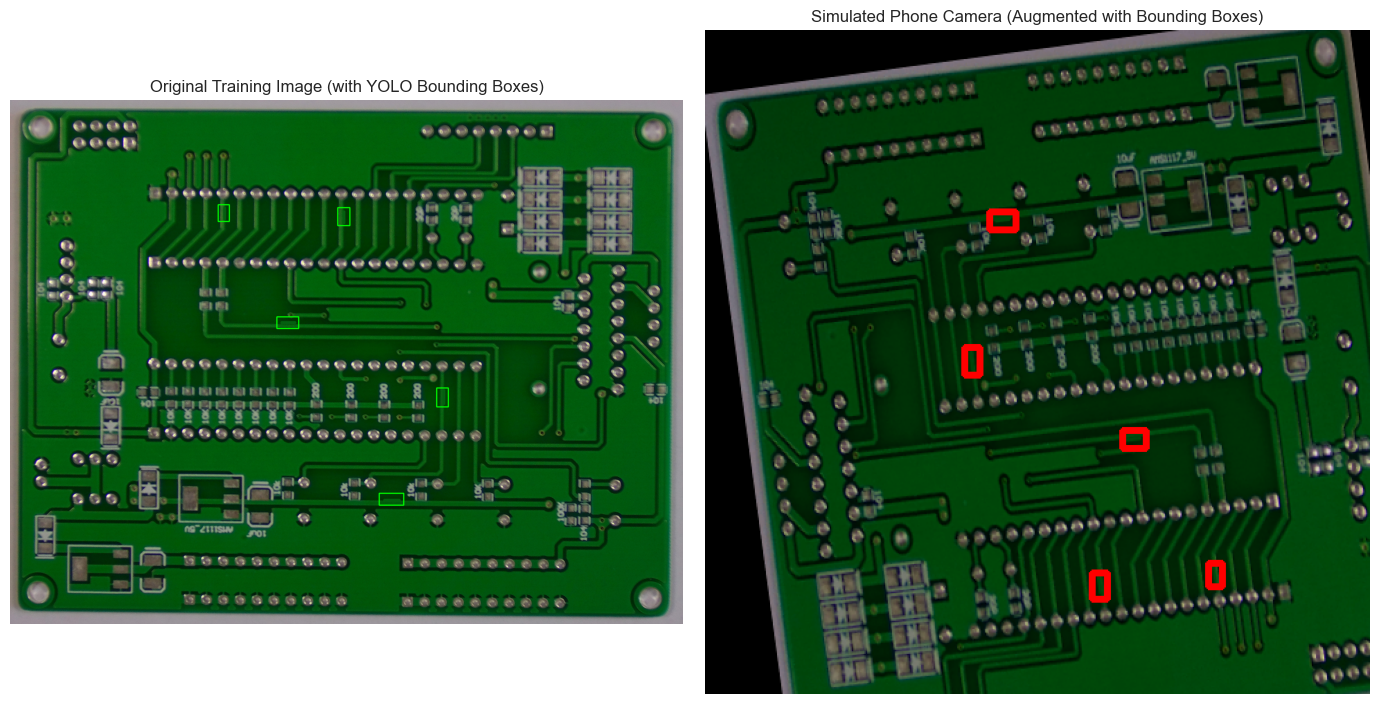

In [42]:
import albumentations as A
import cv2
import random

# Helper function to draw YOLO boxes
def draw_yolo_boxes(img, bboxes, color=(255, 0, 0), thickness=2):
    img_copy = img.copy()
    h, w, _ = img_copy.shape
    for bbox in bboxes:
        # YOLO format: [x_center, y_center, width, height] normalized
        x_center, y_center, box_w, box_h = bbox
        x_min = int((x_center - box_w/2) * w)
        y_min = int((y_center - box_h/2) * h)
        x_max = int((x_center + box_w/2) * w)
        y_max = int((y_center + box_h/2) * h)
        cv2.rectangle(img_copy, (x_min, y_min), (x_max, y_max), color, thickness)
    return img_copy

# Find a random image and its corresponding label
img_paths = glob.glob(os.path.join(RAW_IMG_DIR, "*.jpg"))
sample_img_path = random.choice(img_paths)
filename = os.path.basename(sample_img_path)
lbl_path = os.path.join(RAW_LBL_DIR, os.path.splitext(filename)[0] + ".txt")

image = cv2.cvtColor(cv2.imread(sample_img_path), cv2.COLOR_BGR2RGB)

# Read Bounding Boxes
bboxes = []
class_labels = []
if os.path.exists(lbl_path):
    with open(lbl_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                bboxes.append([float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])])
                class_labels.append(int(parts[0]))

# The actual augmentation pipeline with bounding box support
transform = A.Compose([
    A.Resize(height=480, width=480),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.95, 1.05), rotate=[-10, 10], p=0.4, fill=0),
    A.Perspective(scale=(0.02, 0.08), p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), sigma_limit=(0.1, 1.5), p=0.2),
    A.GaussNoise(std_range=(0.005, 0.015), mean_range=(0.0, 0.0), p=0.2),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.2))

# Apply transformations
transformed = transform(image=image, bboxes=bboxes, class_labels=class_labels)
aug_image = transformed['image']
aug_bboxes = transformed['bboxes']

# Draw boxes on both images
img_with_boxes = draw_yolo_boxes(image, bboxes, color=(0, 255, 0), thickness=3)
aug_with_boxes = draw_yolo_boxes(aug_image, aug_bboxes, color=(255, 0, 0), thickness=3)

# Plot before and after
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(img_with_boxes)
ax[0].set_title("Original Training Image (with YOLO Bounding Boxes)")
ax[0].axis('off')

ax[1].imshow(aug_with_boxes)
ax[1].set_title("Simulated Phone Camera (Augmented with Bounding Boxes)")
ax[1].axis('off')

plt.tight_layout()
plt.show()

# **Dataset Augmentation Impact Analysis**

Analyzing 2772 augmented images for Blur and Brightness...


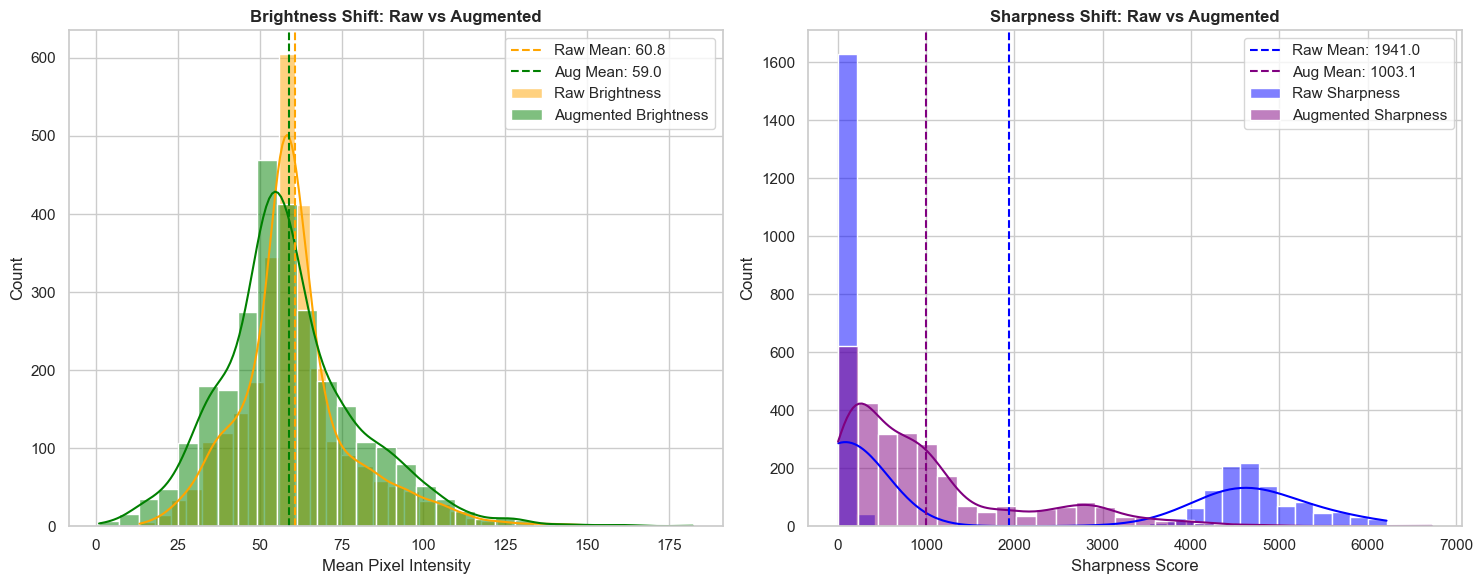

In [44]:
# Calculate the blur and brightness for augmented images
aug_metrics_data = []
aug_img_paths = glob.glob("../data/augmented/train/images/*.jpg")

print(f"Analyzing {len(aug_img_paths)} augmented images for Blur and Brightness...")

for img_path in aug_img_paths:
    img = cv2.imread(img_path)
    if img is None: 
        continue
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = np.mean(gray)
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    
    aug_metrics_data.append({"Image": os.path.basename(img_path), "Brightness": brightness, "Blur_Score": blur_score})

df_aug_metrics = pd.DataFrame(aug_metrics_data)

# Plot Before vs After Distributions overlaying each other
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Brightness Comparison
sns.histplot(data=df_metrics, x="Brightness", bins=30, kde=True, ax=axes[0], color="orange", label="Raw Brightness")
sns.histplot(data=df_aug_metrics, x="Brightness", bins=30, kde=True, ax=axes[0], color="green", label="Augmented Brightness")
axes[0].set_title("Brightness Shift: Raw vs Augmented", fontweight='bold')
axes[0].set_xlabel("Mean Pixel Intensity")
axes[0].axvline(df_metrics['Brightness'].mean(), color='orange', linestyle='--', label=f"Raw Mean: {df_metrics['Brightness'].mean():.1f}")
axes[0].axvline(df_aug_metrics['Brightness'].mean(), color='green', linestyle='--', label=f"Aug Mean: {df_aug_metrics['Brightness'].mean():.1f}")
axes[0].legend()

# Sharpness Comparison
sns.histplot(data=df_metrics, x="Blur_Score", bins=30, kde=True, ax=axes[1], color="blue", label="Raw Sharpness")
sns.histplot(data=df_aug_metrics, x="Blur_Score", bins=30, kde=True, ax=axes[1], color="purple", label="Augmented Sharpness")
axes[1].set_title("Sharpness Shift: Raw vs Augmented", fontweight='bold')
axes[1].set_xlabel("Sharpness Score")
axes[1].axvline(df_metrics['Blur_Score'].mean(), color='blue', linestyle='--', label=f"Raw Mean: {df_metrics['Blur_Score'].mean():.1f}")
axes[1].axvline(df_aug_metrics['Blur_Score'].mean(), color='purple', linestyle='--', label=f"Aug Mean: {df_aug_metrics['Blur_Score'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

# **Spatial Defect Distribution (Heatmap)**

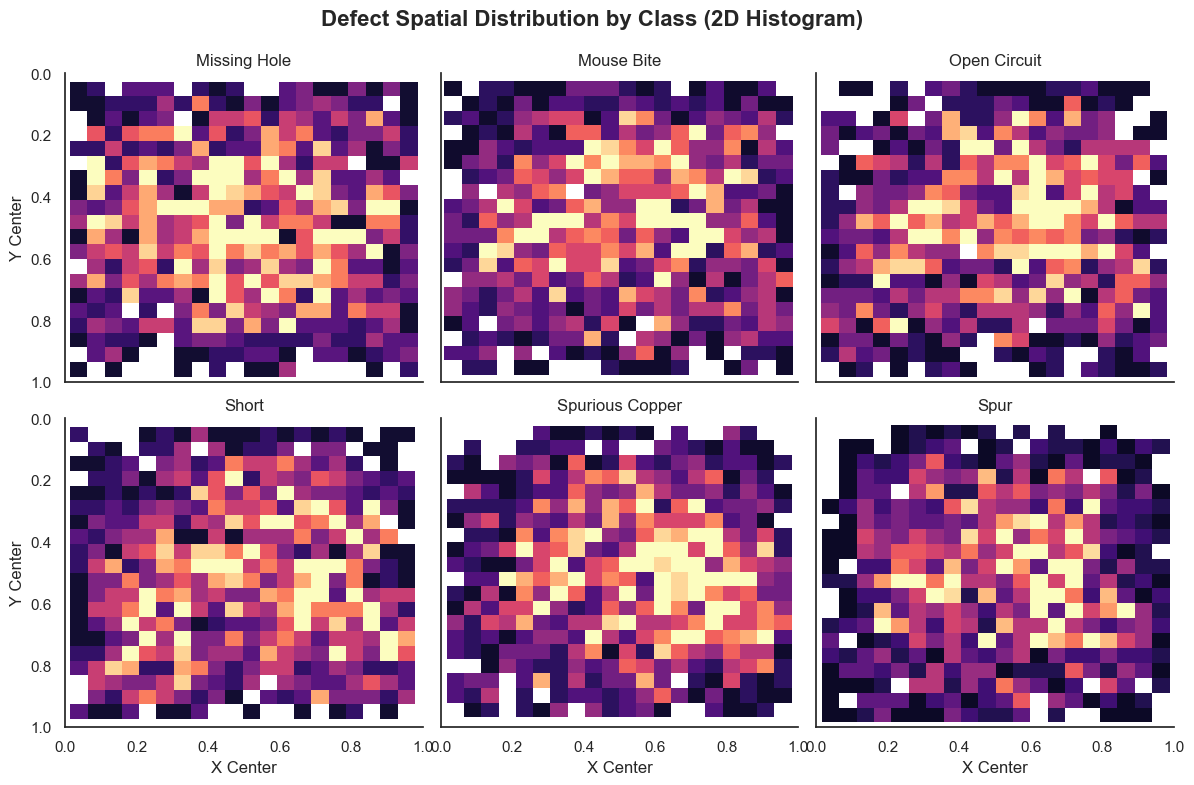

In [48]:
# Extract spatial coordinates (x_center and y_center) for all defects to build a heatmap
spatial_data = []

for lbl_path in glob.glob(os.path.join(RAW_LBL_DIR, "*.txt")):
    with open(lbl_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                # Append standard YOLO coordinates (x_center, y_center)
                spatial_data.append({"Class": CLASS_NAMES.get(int(parts[0]), "Unknown"), 
                                     "x_center": float(parts[1]), 
                                     "y_center": float(parts[2])})

df_spatial = pd.DataFrame(spatial_data)

# Let's drop the "microorganism" scatter plot and create a clean grid of 2D Histograms!
sns.set_theme(style="white")
g = sns.FacetGrid(df_spatial, col="Class", col_wrap=3, height=4, sharex=True, sharey=True)

# Use a 2D histogram instead of KDE for a much cleaner, blocky heatmap look
g.map_dataframe(sns.histplot, x="x_center", y="y_center", bins=20, cmap="magma", pmax=0.8, cbar=False)

g.set_axis_labels("X Center", "Y Center")
g.set_titles(col_template="{col_name}")

# Invert Y-axis for all subplots because Y=0 is the top of an image
for ax in g.axes.flat:
    ax.set_ylim(1, 0)
    ax.set_xlim(0, 1)

g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Defect Spatial Distribution by Class (2D Histogram)", fontsize=16, fontweight='bold')
plt.show()